24BAD056 - M.Karthik Saravanakumar
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Log Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


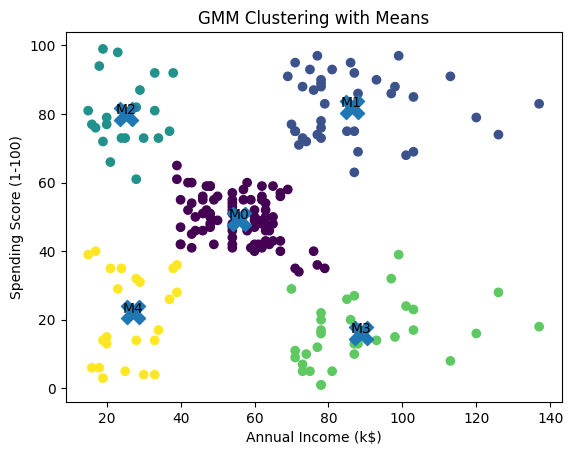

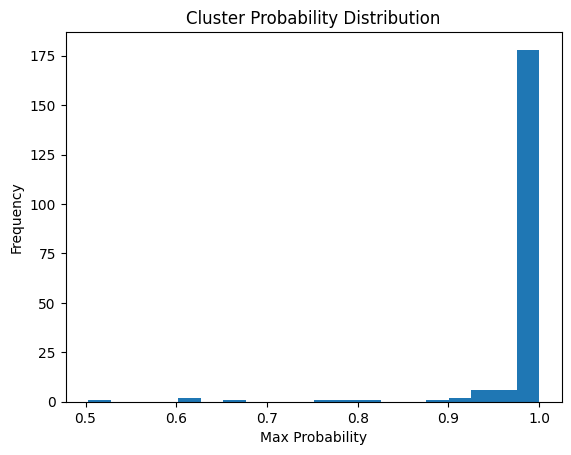

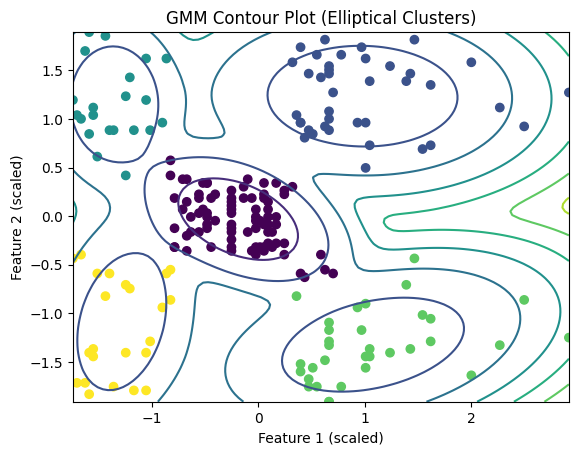

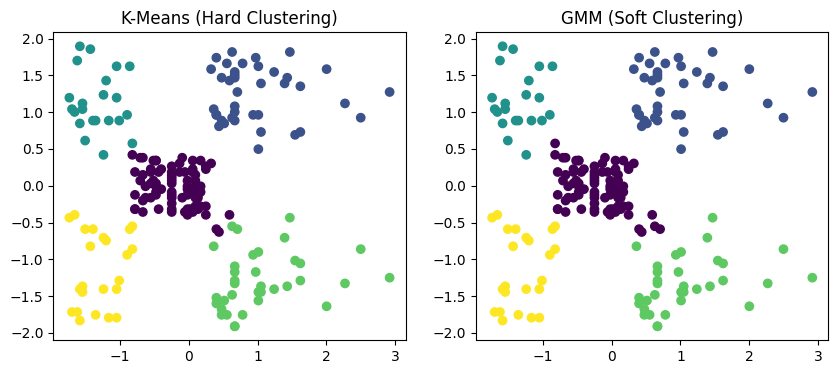


Cluster-wise Mean Values:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.714286           55.642857               49.369048
1        32.692308           86.538462               82.128205
2        25.333333           25.095238               80.047619
3        40.454545           88.818182               16.000000
4        45.217391           26.304348               20.913043

Gender Distribution:
Cluster  Gender
0        Female    50
         Male      34
1        Female    21
         Male      18
2        Female    12
         Male       9
3        Male      18
         Female    15
4        Female    14
         Male       9
Name: count, dtype: int64

Cluster Probabilities (First 5 Rows):
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.

In [ ]:
print("24BAD052 - B.Kalvi Kannan")
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2. Load Dataset
data = pd.read_csv("Mall_Customers.csv")
print(data.head())

# 3. Preprocessing
print("\nMissing Values:\n", data.isnull().sum())
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply GMM (EM Algorithm)
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# 5. Predict Probabilities
probs = gmm.predict_proba(X_scaled)
labels = np.argmax(probs, axis=1)
data['Cluster'] = labels

# 6. Evaluation Metrics
print("\nLog Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, labels))

# 7. Visualization (Original Scale + Means)
X_original = scaler.inverse_transform(X_scaled)
means = scaler.inverse_transform(gmm.means_)

plt.figure()
plt.scatter(X_original[:, 0], X_original[:, 1], c=labels)
plt.scatter(means[:, 0], means[:, 1], s=300, marker='X')

for i, (x, y) in enumerate(means):
    plt.text(x, y, f'M{i}', ha='center')

plt.title("GMM Clustering with Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

# 8. Probability Distribution Plot
plt.figure()
plt.hist(probs.max(axis=1), bins=20)
plt.title("Cluster Probability Distribution")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")
plt.show()

# 9. GMM Contour Plot (Elliptical Clusters)
x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("GMM Contour Plot (Elliptical Clusters)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

# 10. K-Means vs GMM Comparison
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means (Hard Clustering)")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("GMM (Soft Clustering)")
plt.show()

# 11. Cluster Interpretation
print("\nCluster-wise Mean Values:")
print(data.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())
print("\nGender Distribution:")
print(data.groupby('Cluster')['Gender'].value_counts())

# 12. Show Probabilities (Sample)
print("\nCluster Probabilities (First 5 Rows):")
print(probs[:5])